# Methods for creating wavelength lookup tables

In this notebook, we go through the different methods that can be used to construct a wavelength lookup table,
which is what predicts the most likely wavelength of a neutron arriving at the detector, given its arrival time `event_time_offset`.

The three methods are the following:

- `'simulation'`: create the lookup table by simulating individual neutrons traveling through the chopper system using the `tof` Monte-Carlo package.
- `'analytical'`: create the lookup table using analytical formulas to propagate and chop a pulse of neutrons through the chopper cascade.
- `'file'`: read a pre-computed lookup table from a file.

In [1]:
import scipp as sc
import plopp as pp
import scippnexus as snx
from scippneutron.chopper import DiskChopper
from ess.reduce import unwrap
from ess.reduce.nexus.types import AnyRun, Position

## Beamline setup

In [2]:
psc1 = DiskChopper(
    frequency=sc.scalar(14.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(286 - 180, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -70.405], unit="m"),
    slit_begin=sc.array(
        dims=["cutout"],
        values=[-1.23, 70.49, 84.765, 113.565, 170.29, 271.635, 286.035, 301.17],
        unit="deg",
    ),
    slit_end=sc.array(
        dims=["cutout"],
        values=[1.23, 73.51, 88.035, 116.835, 175.31, 275.565, 289.965, 303.63],
        unit="deg",
    ),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

psc2 = DiskChopper(
    frequency=sc.scalar(-14.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(-236, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -70.395], unit="m"),
    slit_begin=sc.array(
        dims=["cutout"],
        values=[-1.23, 27.0, 55.8, 142.385, 156.765, 214.115, 257.23, 315.49],
        unit="deg",
    ),
    slit_end=sc.array(
        dims=["cutout"],
        values=[1.23, 30.6, 59.4, 145.615, 160.035, 217.885, 261.17, 318.11],
        unit="deg",
    ),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

oc = DiskChopper(
    frequency=sc.scalar(14.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(297 - 180 - 90, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -70.376], unit="m"),
    slit_begin=sc.array(dims=["cutout"], values=[-27.6 * 0.5], unit="deg"),
    slit_end=sc.array(dims=["cutout"], values=[27.6 * 0.5], unit="deg"),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

bcc = DiskChopper(
    frequency=sc.scalar(112.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(240 - 180, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -66.77], unit="m"),
    slit_begin=sc.array(dims=["cutout"], values=[-36.875, 143.125], unit="deg"),
    slit_end=sc.array(dims=["cutout"], values=[36.875, 216.875], unit="deg"),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

t0 = DiskChopper(
    frequency=sc.scalar(28.0, unit="Hz"),
    beam_position=sc.scalar(0.0, unit="deg"),
    phase=sc.scalar(280 - 180, unit="deg"),
    axle_position=sc.vector(value=[0, 0, -63.5], unit="m"),
    slit_begin=sc.array(dims=["cutout"], values=[-314.9 * 0.5], unit="deg"),
    slit_end=sc.array(dims=["cutout"], values=[314.9 * 0.5], unit="deg"),
    slit_height=sc.scalar(10.0, unit="cm"),
    radius=sc.scalar(30.0, unit="cm"),
)

disk_choppers = {"psc1": psc1, "psc2": psc2, "oc": oc, "bcc": bcc, "t0": t0}

## Method: 'simulation'

This first method creates the lookup table by simulating individual neutrons traveling through the chopper system using the `tof` Monte-Carlo package.

This is slower but can be more accurate if the spread in neutron wavelengths is large at the detector.

Other simulation software such as McStas can also be used to replace `tof` for even better results.

In [3]:
wf = unwrap.GenericUnwrapWorkflow(
    run_types=[AnyRun], monitor_types=[], wavelength_from="simulation"
)

wf[unwrap.LtotalRange[AnyRun, snx.NXdetector]] = (
    sc.scalar(50.0, unit="m"),
    sc.scalar(60.0, unit="m"),
)
wf[unwrap.NumberOfSimulatedNeutrons] = (
    200_000  # Increase this number for more reliable results
)
wf[Position[snx.NXsource, AnyRun]] = sc.vector([0, 0, -76.55], unit="m")
wf[unwrap.DiskChoppers[AnyRun]] = disk_choppers
wf[unwrap.DistanceResolution] = sc.scalar(0.1, unit="m")
wf[unwrap.TimeResolution] = sc.scalar(250.0, unit='us')
wf[unwrap.PulsePeriod] = 1.0 / sc.scalar(14.0, unit="Hz")
wf[unwrap.PulseStrideOffset] = None

table = wf.compute(unwrap.LookupTable[AnyRun, snx.NXdetector])
table.array

<scipp.DataArray>
Dimensions: Sizes[distance:105, event_time_offset:287, ]
Coordinates:
* distance                  float64              [m]  (distance)  [49.8, 49.9, ..., 60.1, 60.2]
* event_time_offset         float64            [µs]  (event_time_offset)  [0, 249.75, ..., 71178.8, 71428.6]
Data:
                            float64             [Å]  (distance, event_time_offset)  [-nan, -nan, ..., -nan, -nan]  [-nan, -nan, ..., -nan, -nan]

The computed table spans a range of distances and can be plotted using:

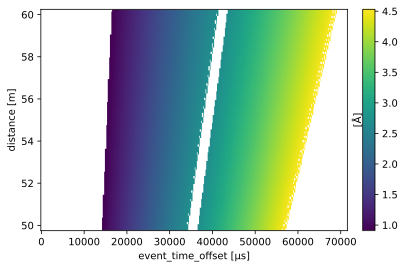

In [4]:
table.plot()

We inspect a horizontal slice of the table around 60m.

The way it was built was to propagate the neutrons in the simulation results read at the position of the last component in the beamline (the `t0` chopper)
to the specified distance of 60m.

We then compute the `event_time_offset` of these neutrons, which is simply their arrival time modulo the pulse period of ~71ms.

Finally, we define `event_time_offset` bin edges (from the `TimeResolution` parameter) and compute the mean observed wavelength inside each bin.

This is illustrated in the figure below where we plot a map of the neutrons in the `(event_time_offset, wavelength)` space.

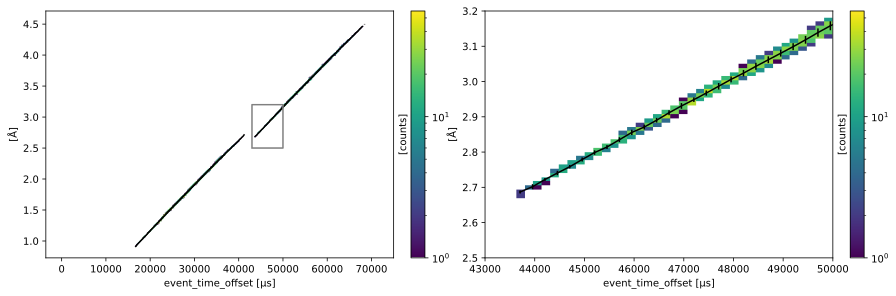

In [5]:
sim = wf.compute(unwrap.SimulationResults[AnyRun])


def to_event_time_offset(sim):
    # Compute event_time_offset at the detector
    eto = (
        sim.time_of_arrival
        + ((table.array.coords['distance'][-1] - sim.distance) / sim.speed).to(
            unit="us"
        )
    ) % sc.scalar(1e6 / 14.0, unit="us")
    return sc.DataArray(
        data=sim.weight,
        coords={"wavelength": sim.wavelength, "event_time_offset": eto},
    )


events = to_event_time_offset(sim.readings["t0"])
hist = events.hist(wavelength=300, event_time_offset=300).plot(norm="log")

fig = pp.tiled(nrows=1, ncols=2)

fig[0, 0] = hist
fig[0, 1] = hist

# Overlay mean on the figure above
table.array["distance", -1].plot(ax=fig[0, 0].ax, color="k", ls="-", marker=None)
table.array["distance", -1].plot(ax=fig[0, 1].ax, color="k", ls="-", marker=None)

xr = 43000, 50000
yr = 2.5, 3.2

fig[0, 0].ax.plot(
    [xr[0], xr[1], xr[1], xr[0], xr[0]],
    [yr[0], yr[0], yr[1], yr[1], yr[0]],
    color='grey',
)
fig[0, 1].canvas.xrange = 43000, 50000
fig[0, 1].canvas.yrange = 2.5, 3.2

fig

We can see that the values from lookup table (black line) follow the centerline of the colored areas in the 2d histogram.

## Method: 'analytical'

This second method creates the lookup table using analytical formulas to propagate and chop a pulse of neutrons through the chopper cascade.

This is fast enough to be performed on-the-fly during data reduction, and should be the default for most reduction workflows.

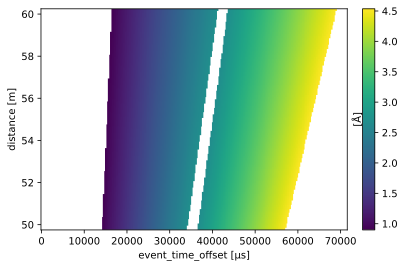

In [6]:
wf = unwrap.GenericUnwrapWorkflow(
    run_types=[AnyRun], monitor_types=[], wavelength_from="analytical"
)

wf[unwrap.LtotalRange[AnyRun, snx.NXdetector]] = (
    sc.scalar(50.0, unit="m"),
    sc.scalar(60.0, unit="m"),
)
wf[Position[snx.NXsource, AnyRun]] = sc.vector([0, 0, -76.55], unit="m")
wf[unwrap.DiskChoppers[AnyRun]] = disk_choppers
wf[unwrap.DistanceResolution] = sc.scalar(0.1, unit="m")
wf[unwrap.TimeResolution] = sc.scalar(250.0, unit='us')
wf[unwrap.PulsePeriod] = 1.0 / sc.scalar(14.0, unit="Hz")
wf[unwrap.PulseStrideOffset] = None

table = wf.compute(unwrap.LookupTable[AnyRun, snx.NXdetector])
table.plot()

As above, we inspect more closely the same horizontal slice of the table around 60m.

This time, a single pulse of neutrons represented by a polygon spanning a range of times and wavelengths (blue rectangle) is propagated through the chopper system.
It stretches as it travels (slower neutrons arrive later at a given distance) and gets chopped into multiple pieces by the choppers which only let through parts of the original pulse.

In the end, at the detector position, we are left with the pink polygons, which are thin enough to be approximated by a straight line.

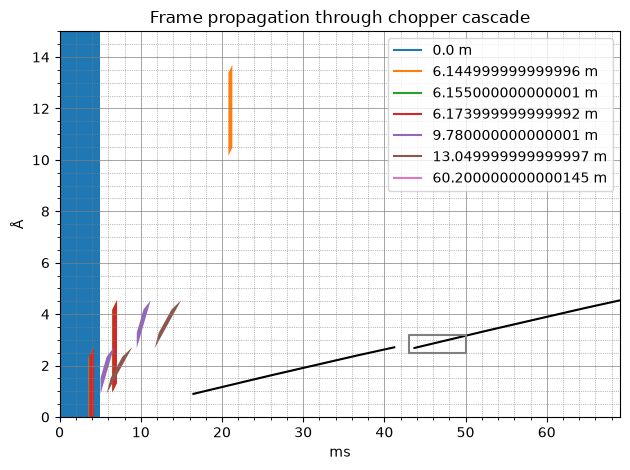

In [7]:
dist = table.array.coords['distance'][-1]

frames = wf.compute(unwrap.ChopperFrameSequence[AnyRun])
at_detector = frames.propagate_to(dist)
fig, ax = at_detector.draw()

table = wf.compute(unwrap.LookupTable[AnyRun, snx.NXdetector])

# Overlay LUT prediction on the polygons figure
da = table.array["distance", -1]
ax.plot(
    da.coords['event_time_offset'].values / 1000,
    da.values,
    color="k",
    ls="-",
    marker=None,
)

xr_ms = xr[0] / 1000, xr[1] / 1000

ax.plot(
    [xr_ms[0], xr_ms[1], xr_ms[1], xr_ms[0], xr_ms[0]],
    [yr[0], yr[0], yr[1], yr[1], yr[0]],
    color='grey',
)

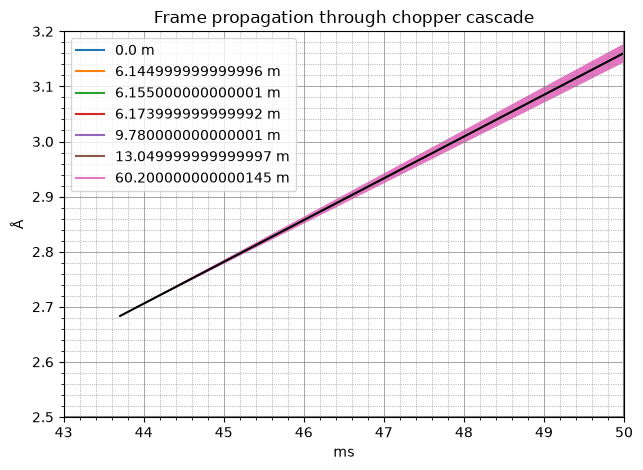

In [8]:
ax.set(xlim=xr_ms, ylim=yr)
fig

The black line following the center of the polygons is what is stored inside the lookup table.

Before the next section, we save the computed table to disk:

In [9]:
table.save_hdf5("wavelength-lut-60m-80m.h5")

Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.


## Method: 'file'

The final method is to simply read a pre-computed lookup table from disk.

This is very easy and convenient to use, but one needs to be sure that the chopper settings used in the run to be reduced were the same that were used to compute the lookup table we are loading.

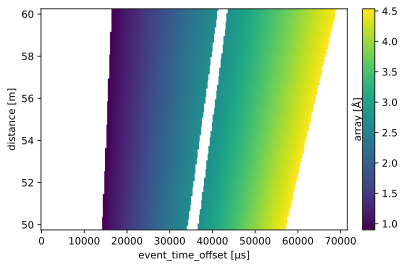

In [10]:
wf = unwrap.GenericUnwrapWorkflow(
    run_types=[AnyRun], monitor_types=[], wavelength_from="file"
)

wf[unwrap.LookupTableFilename[AnyRun, snx.NXdetector]] = "wavelength-lut-60m-80m.h5"

table = wf.compute(unwrap.LookupTable[AnyRun, snx.NXdetector])
table.plot()